# Sales & Demand Forecasting Project

## Sales Trend Analysis

In [49]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
# Load the dataset
df = pd.read_csv(r"C:\Users\lenovo\.jupyter\Sample - Superstore.csv", encoding='latin1')
# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [51]:
## Data Loading
##In this step, we import and load the dataset for analysis.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [52]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [53]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [54]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [55]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [56]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales = daily_sales.sort_values('Order Date')

## Exploratory Data Analysis (EDA)
We visualize the data to understand patterns and trends.

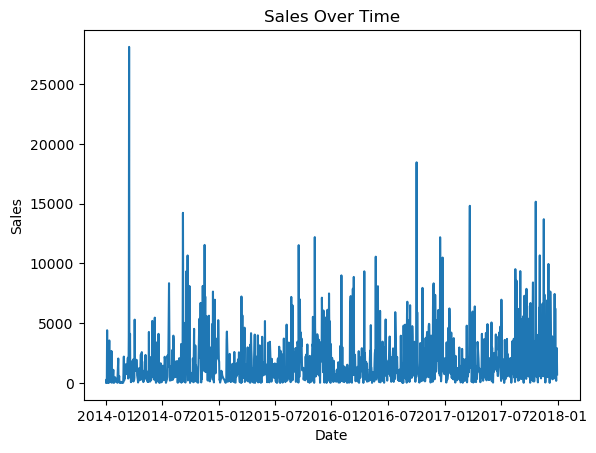

In [57]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(daily_sales['Order Date'], daily_sales['Sales'])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

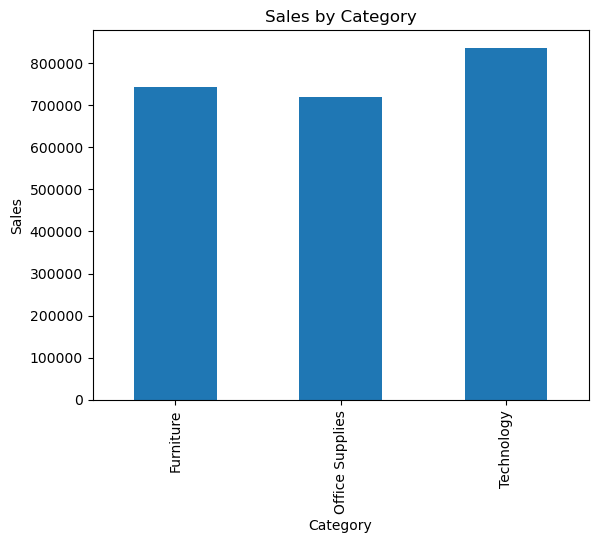

In [58]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [59]:
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day

In [60]:
daily_sales['Days'] = (daily_sales['Order Date'] - daily_sales['Order Date'].min()).dt.days

# Using Linear Regression to predict future sales based on time trend

In [61]:
from sklearn.linear_model import LinearRegression

X = daily_sales[['Days']]
y = daily_sales['Sales']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [62]:
future_days = np.arange(daily_sales['Days'].max() + 1,
                        daily_sales['Days'].max() + 31)

future_days = pd.DataFrame(future_days, columns=['Days'])

future_predictions = model.predict(future_days)

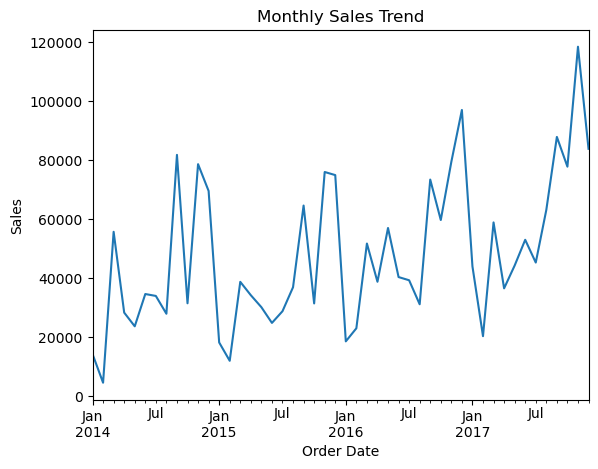

In [63]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.show()

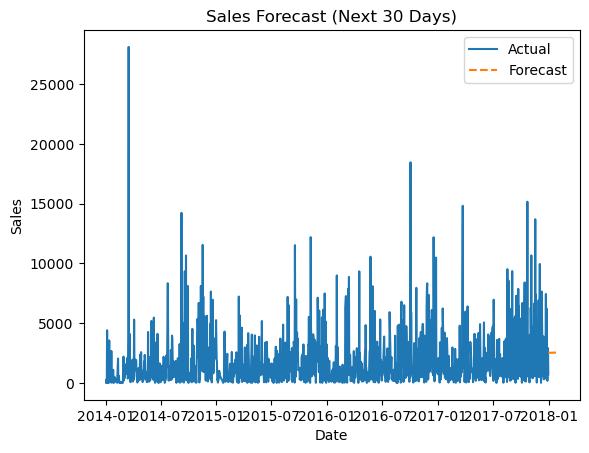

In [64]:
plt.figure()

plt.plot(daily_sales['Order Date'], daily_sales['Sales'], label="Actual")

future_dates = pd.date_range(start=daily_sales['Order Date'].max(), periods=30)

plt.plot(future_dates, future_predictions, linestyle='dashed', label="Forecast")

plt.legend()
plt.title("Sales Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## Business Insights

- Sales show clear variations over time indicating changing demand.
- Monthly trends highlight seasonal patterns in sales.
- Certain product categories contribute significantly to revenue.

### Business Value:
- Helps businesses plan inventory efficiently
- Supports better staffing decisions
- Enables data-driven financial planning